**PROJECT TITLE**

AI-Based Early Warning System for Dengue Case Prediction

**OBJECTIVE**

Explainable Dengue Early Warning System Using Meteorological Data and Machine Learning

# A. IMPORT LIBRARY

In [ ]:
!pip install xgboost catboost shap joblib -q

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import shap
import joblib

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


# B. EXPLORATORY DATA ANALYSIS

In [ ]:
df = pd.read_csv("final.csv")

print(df.shape)
df.head()

(602, 26)


,serial,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations,cases,labels
0,0,34.053151,24.478082,28.709863,39.757808,25.317808,32.306301,22.971233,73.508219,2.921726,...,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.197260,4925.0,normal
1,1,34.086179,25.694309,29.464228,41.338211,28.140650,34.423577,23.484553,72.066667,3.783415,...,1003.533333,48.313821,2.884553,222.926016,19.246341,7.504065,1.658537,0.991870,5077.0,normal
2,2,34.573984,25.417886,29.526829,40.464228,26.560163,33.085366,22.580488,69.424390,3.065854,...,1005.731707,55.621138,4.242276,229.413008,19.802439,7.829268,1.910569,1.170732,7579.0,normal
3,3,33.020325,25.080488,28.727642,37.878049,26.193496,31.772358,21.752033,69.297561,6.025203,...,1003.359350,50.208130,2.991057,225.421951,19.480488,7.593496,1.300813,0.146341,13706.0,normal
4,4,30.660976,24.230894,26.774797,36.586992,24.263415,28.943902,24.214634,86.652033,23.336585,...,1009.995935,45.542276,3.886992,176.598374,15.261789,6.186992,0.967480,3.951220,82.0,normal


In [ ]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   serial            602 non-null    int64  
 1   tempmax           602 non-null    float64
 2   tempmin           602 non-null    float64
 3   temp              602 non-null    float64
 4   feelslikemax      602 non-null    float64
 5   feelslikemin      602 non-null    float64
 6   feelslike         602 non-null    float64
 7   dew               602 non-null    float64
 8   humidity          602 non-null    float64
 9   precip            602 non-null    float64
 10  precipprob        602 non-null    float64
 11  precipcover       602 non-null    float64
 12  snow              602 non-null    float64
 13  snowdepth         602 non-null    float64
 14  windspeed         602 non-null    float64
 15  winddir           602 non-null    float64
 16  sealevelpressure  602 non-null    float64
 1

,serial,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations,cases
count,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,...,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000
mean,300.500000,31.918079,24.588318,27.813181,38.476069,25.613154,31.485111,23.984349,81.254786,13.120862,...,191.498693,1004.690531,59.701192,3.632620,199.802695,17.251785,6.877674,1.827725,0.859734,8502.342193
std,173.926709,2.737215,2.727919,2.412416,4.776400,4.178797,4.672951,2.668014,9.406354,28.463365,...,81.604668,41.364967,20.832639,1.890352,54.128192,4.676051,1.763928,1.237389,0.973575,6780.749627
min,0.000000,25.000000,12.740000,18.820000,25.000000,12.360000,18.626667,4.480000,40.833333,0.000000,...,0.500000,0.000000,0.000000,0.800000,57.900000,5.000000,2.000000,0.000000,0.000000,52.000000
25%,150.250000,30.025000,23.200000,26.500000,35.600000,23.200000,28.100000,23.300000,75.800000,0.000000,...,134.425000,1002.025000,47.400000,2.523780,160.350000,13.900000,6.000000,1.000000,0.000000,3017.750000
50%,300.500000,31.700000,25.000000,27.900000,38.400000,25.000000,31.500000,24.529268,82.800000,3.000000,...,207.300000,1007.000000,63.700000,3.200000,205.750000,17.750000,7.000000,2.000000,1.000000,7490.000000
75%,450.750000,33.600000,26.500000,29.448171,41.900000,26.600000,34.875000,25.475000,88.175000,12.589000,...,252.375000,1010.185772,73.200000,4.300000,238.800610,20.600610,8.000000,3.000000,1.000000,12702.500000
max,601.000000,41.200000,29.400000,33.300000,49.600000,37.900000,42.900000,28.100000,99.300000,302.000000,...,359.200000,1020.000000,97.900000,24.033333,318.500000,27.700000,10.000000,4.000000,5.000000,24983.000000


In [ ]:
df.isnull().sum()

,0
serial,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
dew,0
humidity,0
precip,0


In [ ]:
df.columns

Index(['serial', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
       'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'conditions', 'stations', 'cases', 'labels'],
      dtype='object')

In [ ]:
df["cases"].describe()

,cases
count,602.000000
mean,8502.342193
std,6780.749627
min,52.000000
25%,3017.750000
50%,7490.000000
75%,12702.500000
max,24983.000000


In [ ]:
df = df.drop(
    columns=[
        "serial",
        "labels"
    ]
)

In [ ]:
df.columns

Index(['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
       'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'conditions', 'stations', 'cases'],
      dtype='object')

## Distribution of Cases

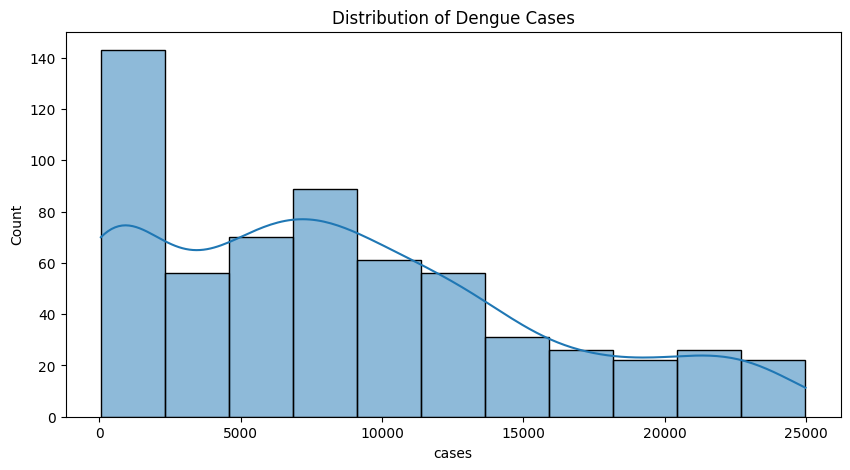

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["cases"],
    kde=True
)

plt.title("Distribution of Dengue Cases")

plt.show()

## LOG Transformation

In [ ]:
df["cases_log"] = np.log1p(
    df["cases"]
)

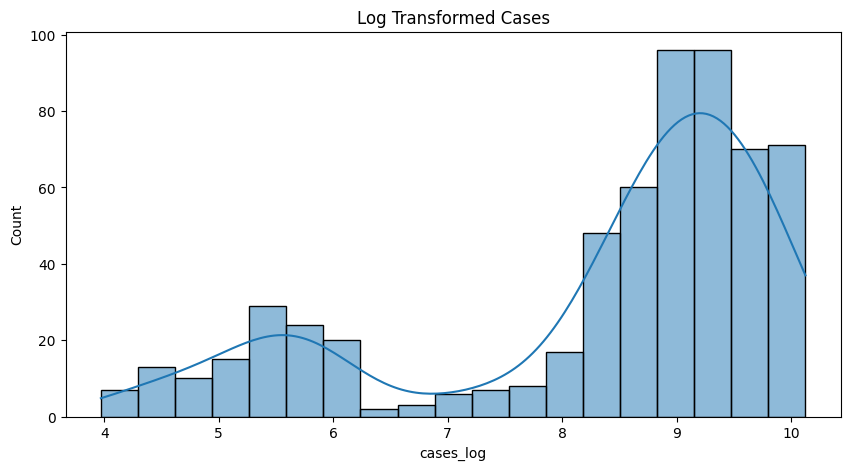

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["cases_log"],
    kde=True
)

plt.title("Log Transformed Cases")

plt.show()

## Correlation Heatmap

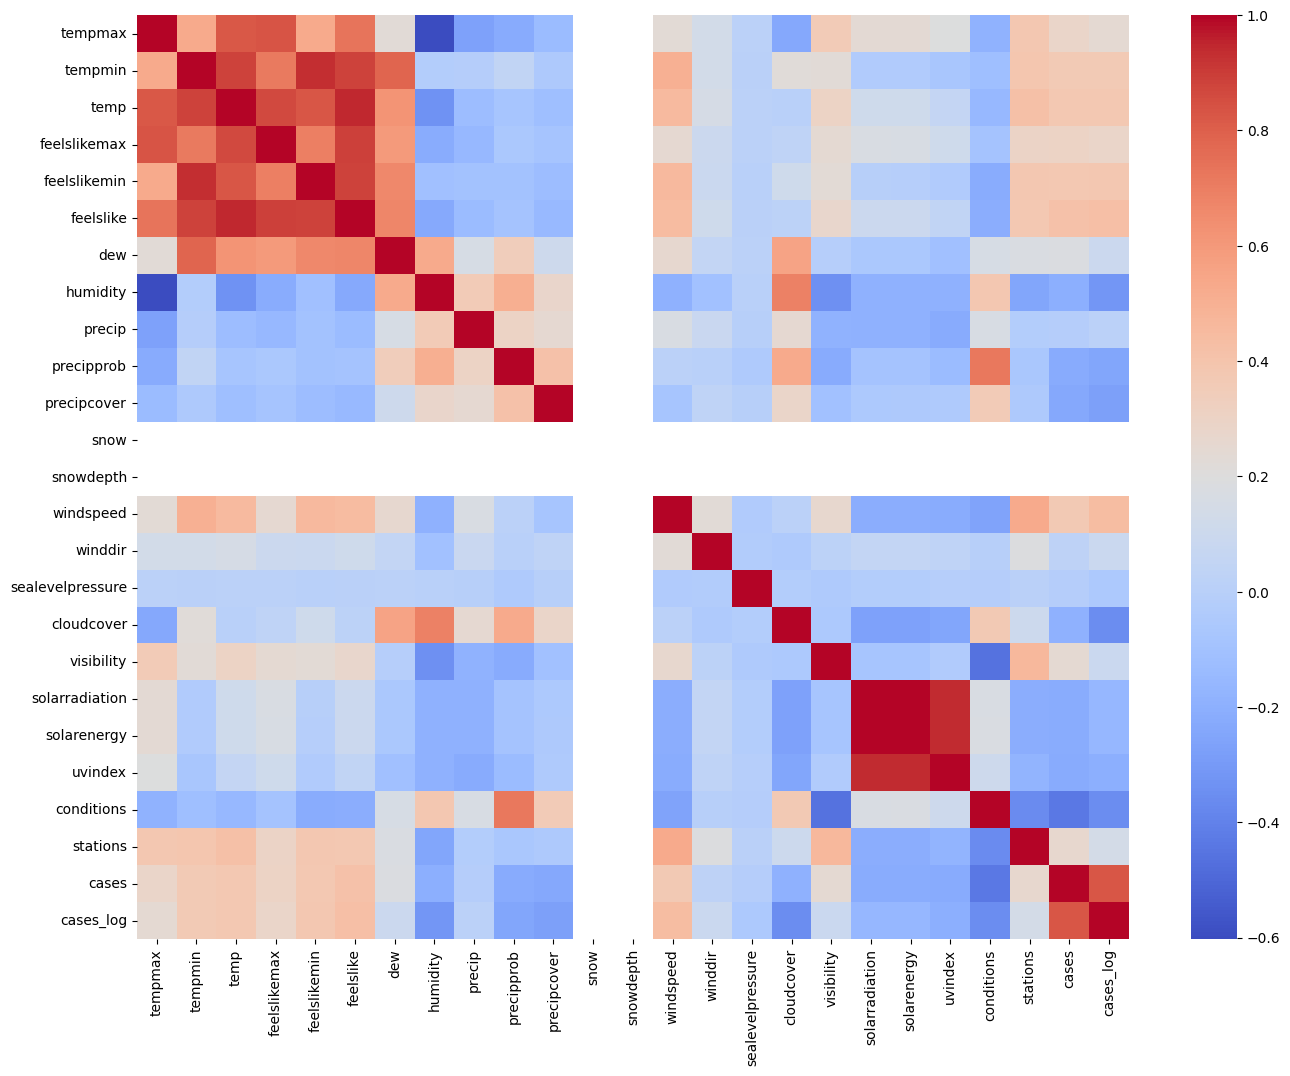

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

# C. EPIDEMIOLOGICAL FEATURE ENGINEERING

## Rainfall Lag

In [ ]:
for lag in [1,2,4,8]:

    df[f"precip_lag_{lag}"] = (
        df["precip"]
        .shift(lag)
    )

## Wind Speed Lag Lag

In [ ]:
for lag in [1,2,4]:

    df[f"windspeed_lag_{lag}"] = (
        df["windspeed"]
        .shift(lag)
    )

## Humidity Lag

In [ ]:
for lag in [1,2,4,8]:

    df[f"humidity_lag_{lag}"] = (
        df["humidity"]
        .shift(lag)
    )

## Temperature Lag

In [ ]:
for lag in [1,2,4,8]:

    df[f"temp_lag_{lag}"] = (
        df["temp"]
        .shift(lag)
    )

## Solar Radiation Lag

In [ ]:
for lag in [1,2,4]:

    df[f"solarradiation_lag_{lag}"] = (
        df["solarradiation"]
        .shift(lag)
    )

# D. DATA PREPROCESSING

## Remove NA

In [ ]:
df = df.dropna()

print(df.shape)

(594, 43)


## Feature Selection



In [ ]:
# Target
y = df["cases_log"]

# Features
drop_cols = [

    "cases",
    "cases_log"

]

X = df.drop(
    columns=drop_cols
)

In [ ]:
import joblib

feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print("Feature names saved")

Feature names saved


## Train Test Split (TIME SERIES)

In [ ]:
split = int(
    len(df)*0.8
)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# E. DATA MODELLING

## BXGBOOST BASE MODEL

In [ ]:
xgb = XGBRegressor(

    objective="reg:squarederror",

    random_state=42
)

# F. HYPERPARAMETER TUNING

## Hyperparameter Search

In [ ]:
param_grid = {

    "n_estimators":[
        100,
        200,
        300,
        500
    ],

    "max_depth":[
        3,
        4,
        5,
        6,
        8
    ],

    "learning_rate":[
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample":[
        0.7,
        0.8,
        1.0
    ],

    "colsample_bytree":[
        0.7,
        0.8,
        1.0
    ],

    "min_child_weight":[
        1,
        3,
        5
    ]
}

## Tmeseries CV

In [ ]:
tscv = TimeSeriesSplit(
    n_splits=5
)

## Random Search

In [ ]:
search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=50,

    scoring="neg_root_mean_squared_error",

    cv=tscv,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

# G. EVALUATE BEST MODEL

In [ ]:
best_model = search.best_estimator_

print(
    search.best_params_
)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


## PREDICTION

In [ ]:
pred_log = best_model.predict(
    X_test
)

## RETURN TO ORIGINAL SCALE

In [ ]:
pred = np.expm1(
    pred_log
)

actual = np.expm1(
    y_test
)

## EVALUATION FUNCTION

In [ ]:
mae = mean_absolute_error(
    actual,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

r2 = r2_score(
    actual,
    pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 3311.0057444852946
RMSE: 4133.388175382442
R2  : -0.7888600050419312


## Predicted vs Actual

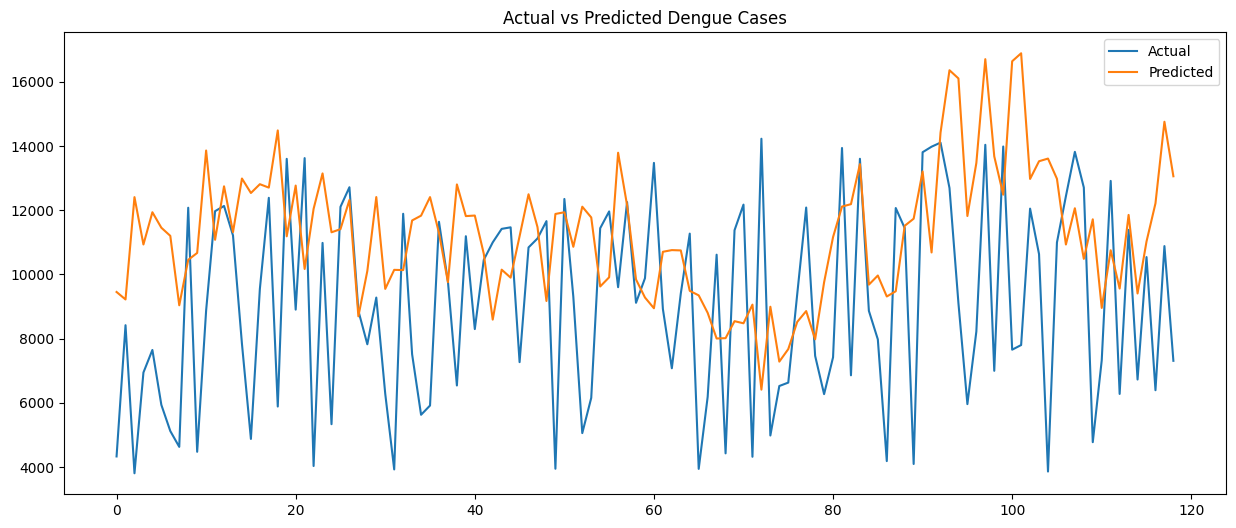

In [ ]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    actual.values,
    label="Actual"
)

plt.plot(
    pred,
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Dengue Cases"
)

plt.show()

# I. FEATURE IMPORTANCE

In [ ]:
importance = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    best_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
16,cloudcover,0.159241
21,conditions,0.106113
20,uvindex,0.058017
1,tempmin,0.057573
15,sealevelpressure,0.051920
35,temp_lag_2,0.045680
27,windspeed_lag_1,0.042240
31,humidity_lag_2,0.042168
17,visibility,0.035718
30,humidity_lag_1,0.033238


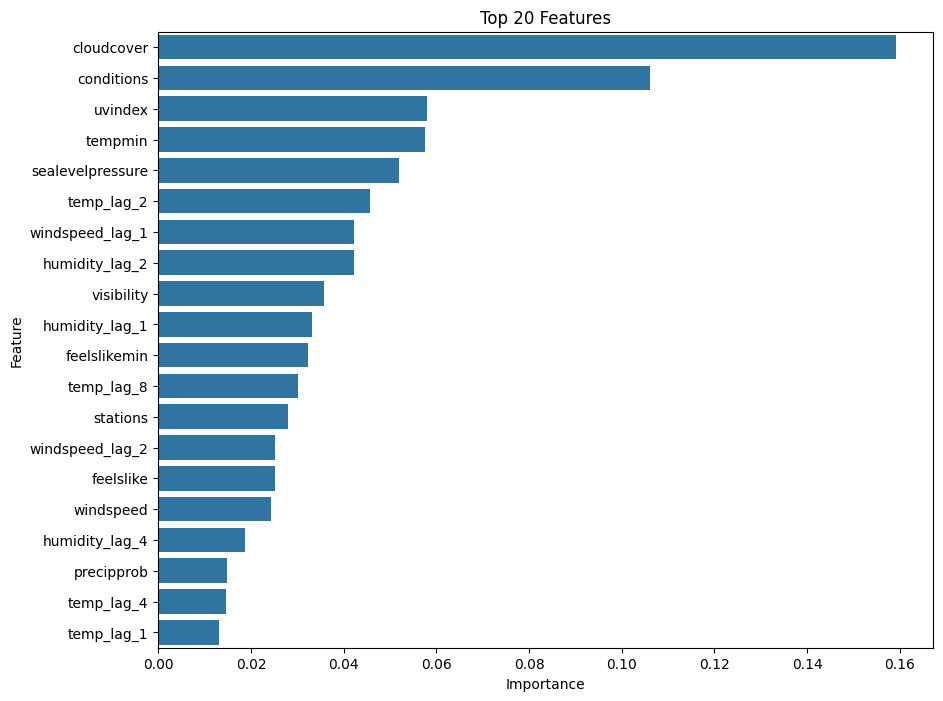

In [ ]:
plt.figure(
    figsize=(10,8)
)

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"
)

plt.title(
    "Top 20 Features"
)

plt.show()

## SHAP

In [ ]:
explainer = shap.TreeExplainer(
    best_model
)

shap_values = (
    explainer.shap_values(
        X_test
    )
)

## SHAP SUMMARY

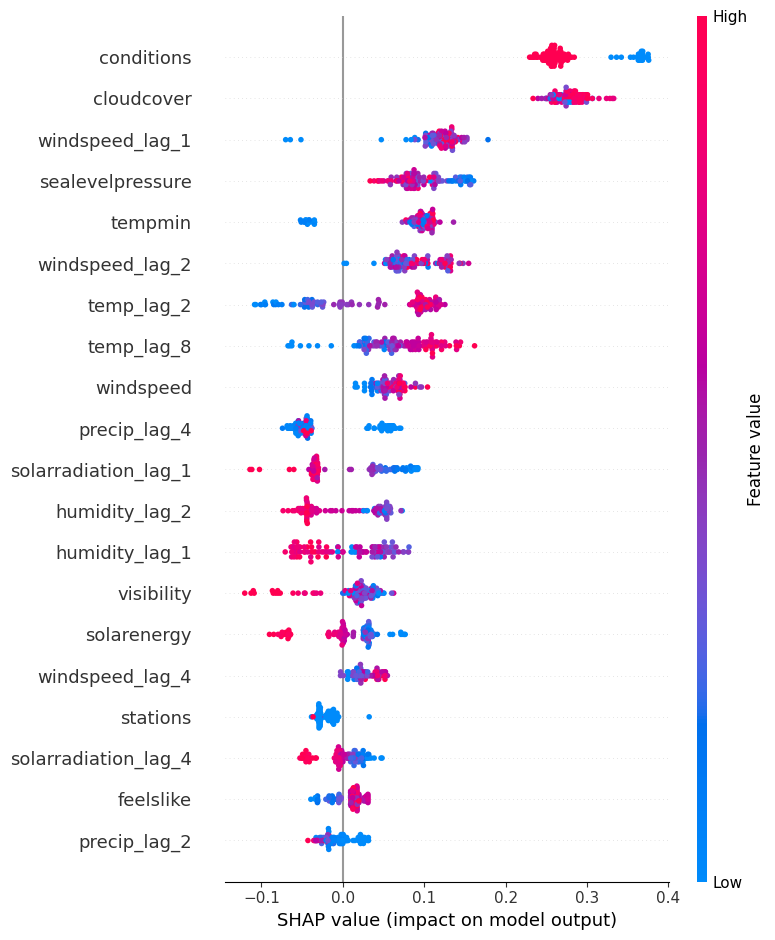

In [ ]:
shap.summary_plot(

    shap_values,

    X_test
)

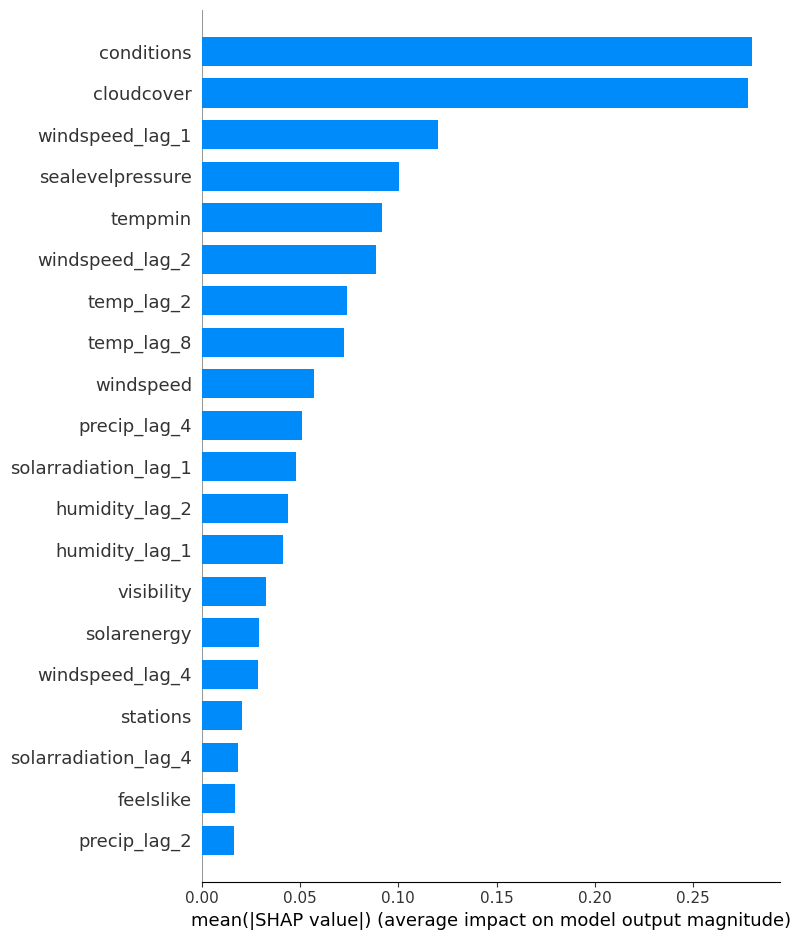

In [ ]:
shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"
)

In [ ]:
importance.head(10)

,Feature,Importance
16,cloudcover,0.159241
21,conditions,0.106113
20,uvindex,0.058017
1,tempmin,0.057573
15,sealevelpressure,0.051920
35,temp_lag_2,0.045680
27,windspeed_lag_1,0.042240
31,humidity_lag_2,0.042168
17,visibility,0.035718
30,humidity_lag_1,0.033238


## SAVE MODEL

In [ ]:
joblib.dump(
    best_model,
    "dengue_xgb_model.pkl"
)

['dengue_xgb_model.pkl']

# J. EARLY WARNING SYSTEM

## HITUNG ENDEMIC CHANNEL THRESHOLD

In [ ]:
mean_cases = df["cases"].mean()

std_cases = df["cases"].std()

print(f"Mean Cases : {mean_cases:.2f}")
print(f"Std Cases  : {std_cases:.2f}")

Mean Cases : 8518.95
Std Cases  : 6810.10


## DEFINISI BATAS RISIKO

In [ ]:
normal_threshold = mean_cases

alert_threshold = mean_cases + std_cases

outbreak_threshold = mean_cases + (2 * std_cases)

print("NORMAL :", normal_threshold)
print("ALERT :", alert_threshold)
print("OUTBREAK :", outbreak_threshold)

NORMAL : 8518.952861952863
ALERT : 15329.054888100729
OUTBREAK : 22139.156914248597


## FUNGSI KLASIFIKASI EWS

In [ ]:
def classify_ews(predicted_cases):

    if predicted_cases < normal_threshold:

        return "NORMAL"

    elif predicted_cases < alert_threshold:

        return "ALERT"

    elif predicted_cases < outbreak_threshold:

        return "OUTBREAK"

    else:

        return "SEVERE OUTBREAK"

## MEMBUAT DATAFRAME EWS

In [ ]:
pred = np.expm1(pred_log)

actual = np.expm1(y_test)

In [ ]:
ews_df = pd.DataFrame({

    "Actual_Cases": actual.values,

    "Predicted_Cases": pred

})

ews_df["Risk_Level"] = (

    ews_df["Predicted_Cases"]

    .apply(classify_ews)

)

ews_df.head()

,Actual_Cases,Predicted_Cases,Risk_Level
0,4334.0,9454.205078,ALERT
1,8420.0,9221.665039,ALERT
2,3810.0,12406.860352,ALERT
3,6947.0,10932.974609,ALERT
4,7649.0,11936.895508,ALERT


## JUMLAH PER KATEGORI RISIKO

In [ ]:
risk_summary = (

    ews_df["Risk_Level"]

    .value_counts()

    .reset_index()

)

risk_summary.columns = [

    "Risk_Level",

    "Count"

]

risk_summary

,Risk_Level,Count
0,ALERT,107
1,NORMAL,7
2,OUTBREAK,5


## VISUALISASI DISTRIBUSI RISIKO

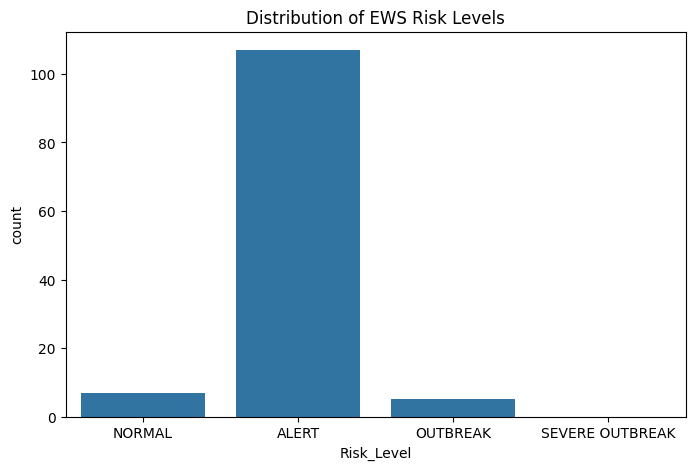

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=ews_df,

    x="Risk_Level",

    order=[

        "NORMAL",

        "ALERT",

        "OUTBREAK",

        "SEVERE OUTBREAK"

    ]

)

plt.title("Distribution of EWS Risk Levels")

plt.show()

## VISUALISASI EARLY WARNING SYSTEM

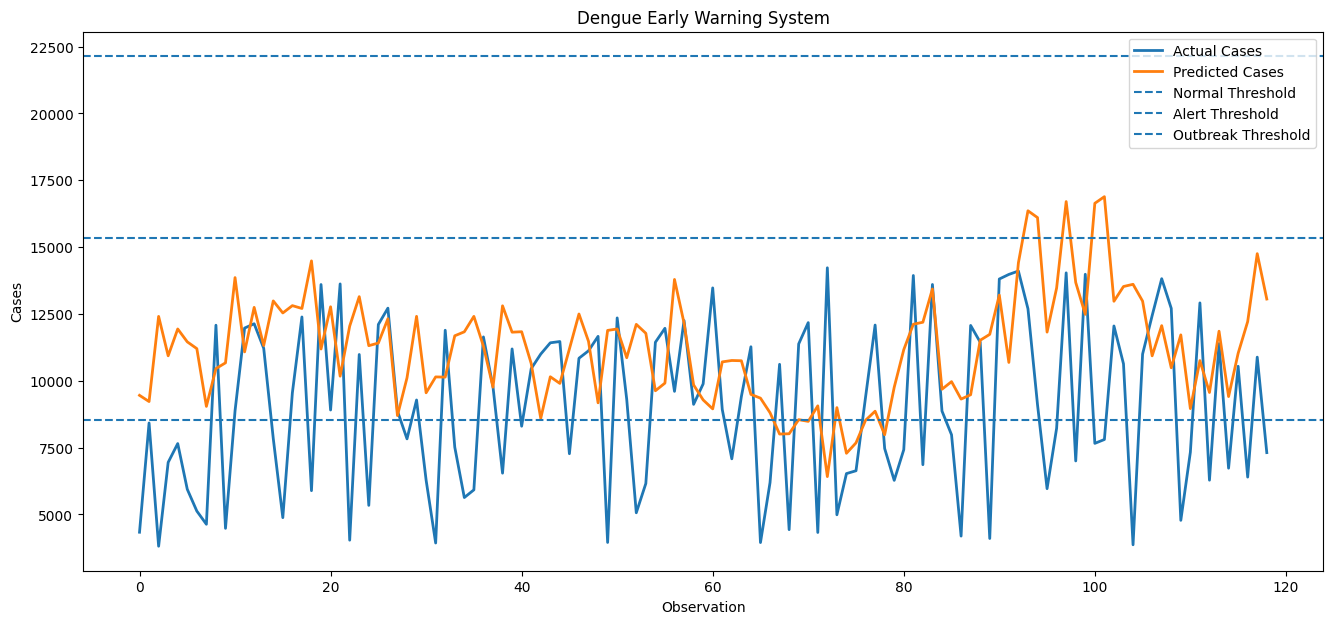

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(

    actual.values,

    label="Actual Cases",

    linewidth=2

)

plt.plot(

    pred,

    label="Predicted Cases",

    linewidth=2

)

plt.axhline(

    normal_threshold,

    linestyle="--",

    label="Normal Threshold"

)

plt.axhline(

    alert_threshold,

    linestyle="--",

    label="Alert Threshold"

)

plt.axhline(

    outbreak_threshold,

    linestyle="--",

    label="Outbreak Threshold"

)

plt.title(

    "Dengue Early Warning System"

)

plt.xlabel("Observation")

plt.ylabel("Cases")

plt.legend()

plt.show()

## IDENTIFIKASI PERINGATAN DINI

In [ ]:
high_risk = ews_df[

    ews_df["Risk_Level"].isin(

        [

            "OUTBREAK",

            "SEVERE OUTBREAK"

        ]

    )

]

high_risk.head(20)

,Actual_Cases,Predicted_Cases,Risk_Level
93,12692.0,16357.785156,OUTBREAK
94,9105.0,16102.415039,OUTBREAK
97,14036.0,16702.083984,OUTBREAK
100,7658.0,16637.203125,OUTBREAK
101,7802.0,16885.441406,OUTBREAK


## AKURASI DETEKSI OUTBREAK

In [ ]:
# Berdasar Data Aktual

ews_df["Actual_Status"] = np.where(

    ews_df["Actual_Cases"]

    >= outbreak_threshold,

    1,

    0

)

In [ ]:
# Berdasar Hasil Model

ews_df["Predicted_Status"] = np.where(

    ews_df["Predicted_Cases"]

    >= outbreak_threshold,

    1,

    0

)

## CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    ews_df["Actual_Status"],

    ews_df["Predicted_Status"]

)

print(cm)

[[119]]


## SAVE EWS RESULT

In [ ]:
ews_df.to_csv(

    "Dengue_EWS_Result.csv",

    index=False

)

print(

    "EWS result saved."

)

EWS result saved.


In [ ]:
ews_threshold = {

    "normal": normal_threshold,

    "alert": alert_threshold,

    "outbreak": outbreak_threshold

}

joblib.dump(
    ews_threshold,
    "ews_threshold.pkl"
)

print("Threshold saved")

Threshold saved


# ADDITIONAL

In [ ]:
import pandas as pd

df = pd.read_csv("final.csv")

print(df.columns.tolist())

['serial', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'conditions', 'stations', 'cases', 'labels']


In [ ]:
import joblib

model = joblib.load("dengue_xgb_model.pkl")

print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
